# Investigate notebook

In [1]:
import pandas as pd
import json

## Load the replay file

In [2]:
replay = '/home/polykiller/detran/hftbacktest/execlab/output/twap_sell/4efee898/replay/5m/tcb/5m_20260702_152930_ET_resolved.json'
with open(replay, "r", encoding="utf-8") as f:
    data = json.load(f)

In [3]:
data.keys()

dict_keys(['alpha', 'hash', 'code_hash', 'market', 'session_id', 'source_file', 'max_inventory', 'n_maker', 'n_taker', 'samples_taken', 'verify', 'fills', 'curve'])

In [ ]:
data['n_taker'] , data['n_maker']

(1000, 0)

In [5]:
data['alpha'] ,data['hash'] , data['market'], data['source_file'], data['max_inventory']

('twap_sell',
 '4efee898',
 '5m/tcb',
 '5m/tcb/5m_20260702_152930_ET_resolved.npz',
 1000.0)

## Fill data

In [19]:
fill_df = pd.DataFrame(data['fills'])
fill_df

,ts,ts_local,order_id,side,px,qty,maker,position,balance,fee
0,1783020570783000000,1783020570773000000,1,sell,0.49,1.0,False,999.0,0.490,0.0
1,1783020570903000000,1783020570893000000,2,sell,0.49,1.0,False,998.0,0.980,0.0
2,1783020571023000000,1783020571013000000,3,sell,0.49,1.0,False,997.0,1.470,0.0
3,1783020571143000000,1783020571133000000,4,sell,0.49,1.0,False,996.0,1.960,0.0
4,1783020571263000000,1783020571253000000,5,sell,0.49,1.0,False,995.0,2.450,0.0
...,...,...,...,...,...,...,...,...,...,...
995,1783020690183000000,1783020690173000000,996,sell,0.41,1.0,False,4.0,458.641,0.0
996,1783020690303000000,1783020690293000000,997,sell,0.41,1.0,False,3.0,459.051,0.0
997,1783020690423000000,1783020690413000000,998,sell,0.43,1.0,False,2.0,459.481,0.0
998,1783020690543000000,1783020690533000000,999,sell,0.35,1.0,False,1.0,459.831,0.0


In [ ]:
1783020570783000000 - 1783020570773000000 

10000000

In [32]:
fill_df.index = pd.to_datetime(fill_df["ts"], unit="ns")

<Axes: xlabel='ts'>

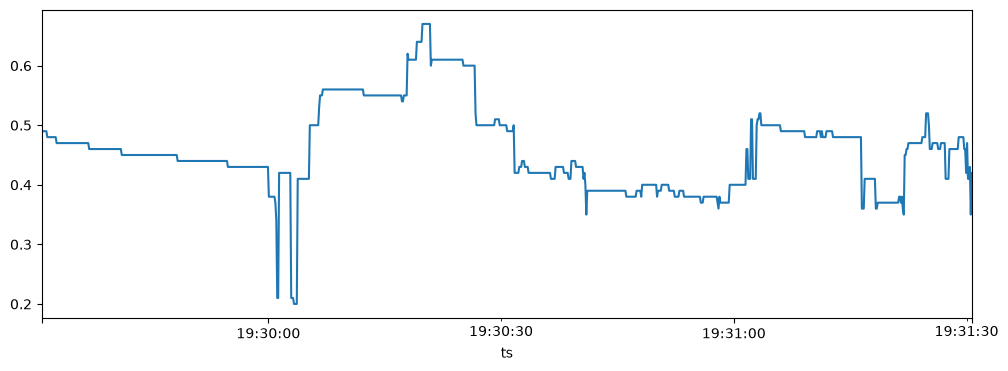

In [34]:
fill_df['px'].plot(figsize=(12, 4))

## Curve data

In [22]:
df = pd.DataFrame(data['curve'])
df

,ts,bid,ask,my_bid,my_ask,position,balance,fee,equity
0,1783020570273000000,NaN,NaN,None,None,1000.0,0.000,0.0,NaN
1,1783020570373000000,NaN,NaN,None,None,1000.0,0.000,0.0,NaN
2,1783020570473000000,NaN,NaN,None,None,1000.0,0.000,0.0,NaN
3,1783020570573000000,NaN,NaN,None,None,1000.0,0.000,0.0,NaN
4,1783020570673000000,NaN,NaN,None,None,1000.0,0.000,0.0,NaN
...,...,...,...,...,...,...,...,...,...
1002,1783020690413000000,0.50,0.54,None,None,3.0,459.051,0.0,460.611
1003,1783020690533000000,0.50,0.54,None,None,2.0,459.481,0.0,460.521
1004,1783020690653000000,0.50,0.54,None,None,1.0,459.831,0.0,460.351
1005,1783020690773000000,0.49,0.54,None,None,0.0,460.251,0.0,460.251


In [26]:
df.index = pd.to_datetime(df["ts"], unit="ns")

<Axes: xlabel='ts'>

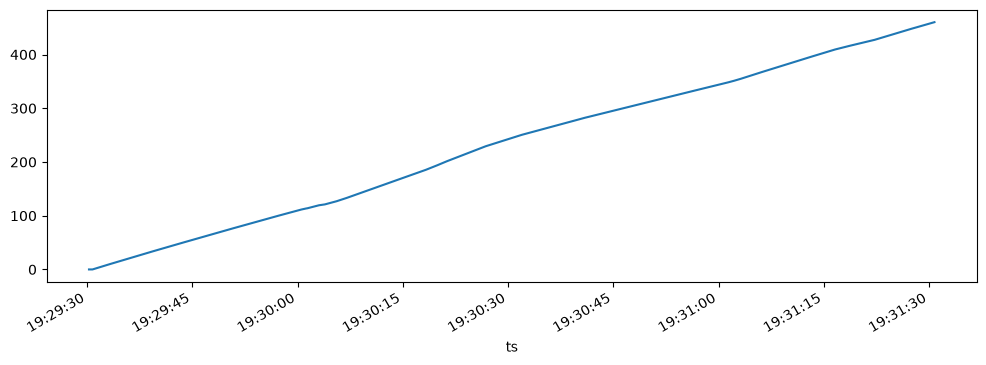

In [27]:
df["balance"].plot(figsize=(12, 4))

<Axes: xlabel='ts'>

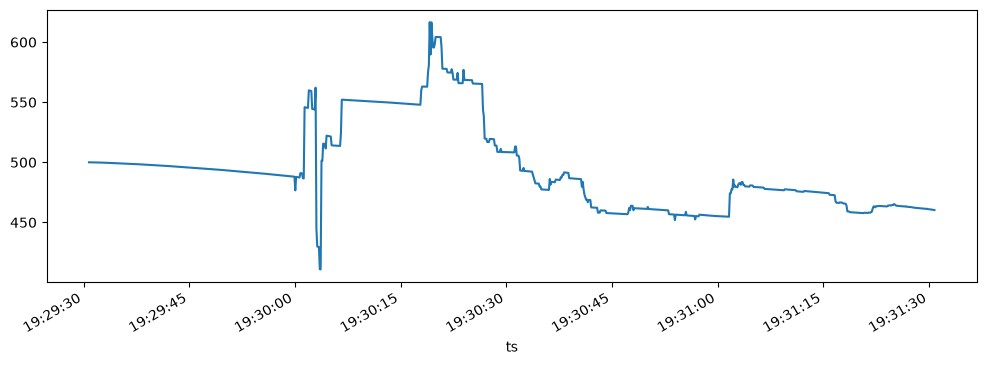

In [28]:
df["equity"].plot(figsize=(12, 4))

<Axes: xlabel='ts'>

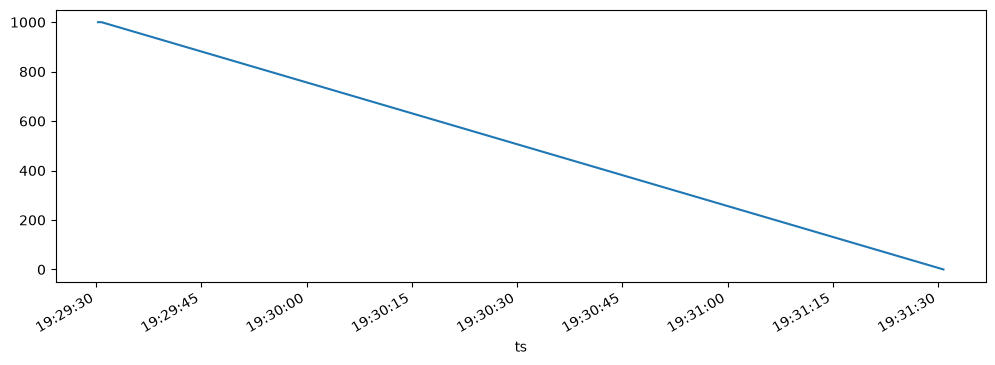

In [29]:
df["position"].plot(figsize=(12, 4))

<Axes: xlabel='ts'>

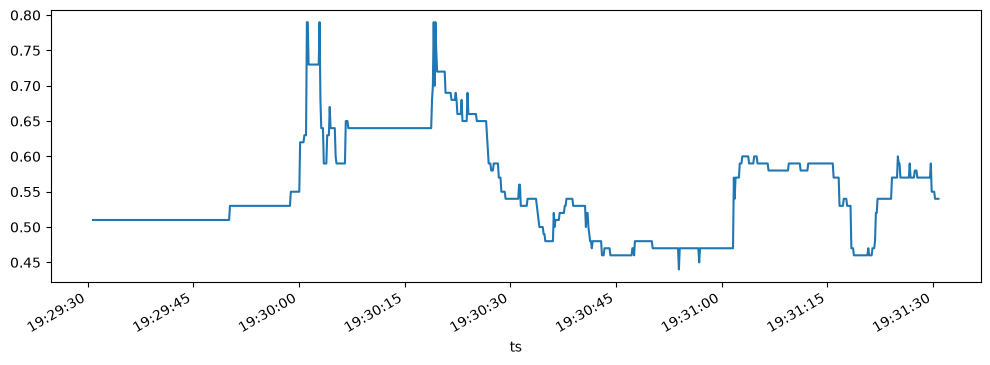

In [30]:
df["ask"].plot(figsize=(12, 4))

<Axes: xlabel='ts'>

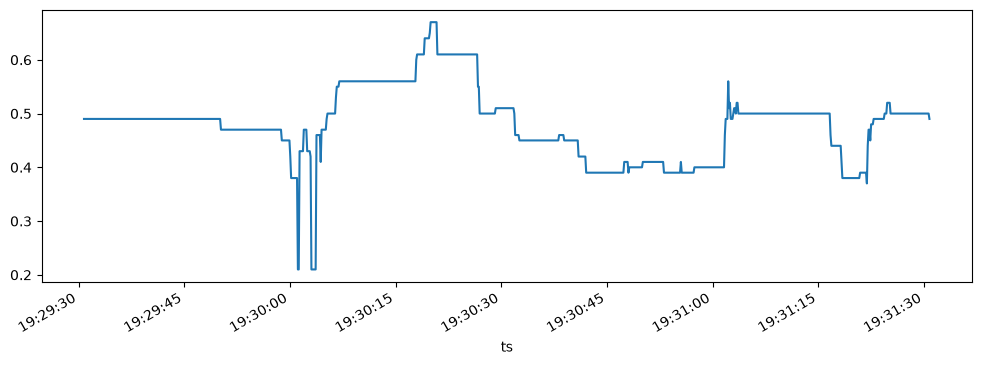

In [31]:
df["bid"].plot(figsize=(12, 4))